# Density propagation through an AE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

import torch
import torch.nn as nn
TRAIN = False

In [2]:
rng = np.random.default_rng(0)

SIGMA = 0.25
LIM = 1.5
IMG_SIZE = 64

def blob_image(theta, sigma=SIGMA, lim=LIM, img_size=IMG_SIZE):
    """Gaussian blob (white) on black background centered at (cos theta, sin theta)."""
    cx, cy = np.cos(theta), np.sin(theta)
    coords = np.linspace(-lim, lim, img_size)
    xx, yy = np.meshgrid(coords, coords)
    img = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2))
    return img

MIX_A = 1  # mixing coefficient: density ∝ a + (1-a)*cos^2(theta/2)

def density_weight(theta, a=MIX_A):
    """Unnormalized circle density ∝ a + (1-a)*cos^2(theta/2), clipped to stay non-negative."""
    return np.clip(a + (1 - a) * np.cos(theta / 2) ** 2, 0, None)

def sample_thetas(n, rng=rng, a=MIX_A):
    """Rejection-sample angles theta ~ a + (1-a)*cos^2(theta/2) on [0, 2pi)."""
    out = np.empty(n)
    filled = 0
    max_w = a + (1 - a)  # density max at theta=0
    while filled < n:
        cand = rng.uniform(0, 2 * np.pi, size=2 * (n - filled))
        accept = rng.uniform(0, max_w, size=cand.shape[0]) < density_weight(cand, a=a)
        accepted = cand[accept]
        take = min(len(accepted), n - filled)
        out[filled:filled + take] = accepted[:take]
        filled += take
    return out

def make_dataset(n_samples, rng=rng, a=MIX_A):
    thetas = sample_thetas(n_samples, rng=rng, a=a)
    imgs = np.stack([blob_image(t) for t in thetas])
    return imgs, thetas

imgs, thetas = make_dataset(10_000)
imgs.shape, thetas.shape

((10000, 64, 64), (10000,))

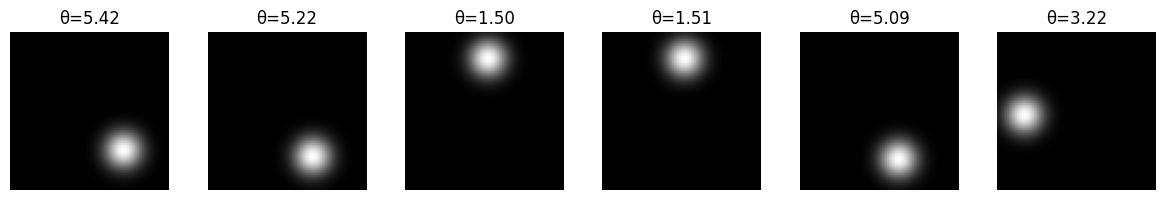

In [3]:
idx = rng.choice(len(imgs), size=6, replace=False)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for ax, i in zip(axes, idx):
    ax.imshow(imgs[i], cmap="gray", vmin=0, vmax=1, extent=[-LIM, LIM, -LIM, LIM], origin="lower")
    ax.set_title(f"θ={thetas[i]:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
FOUR_PI2 = 4 * np.pi ** 2

def _close_loop_trapz(theta_sorted, *fields):
    """Append wrap-around point at theta[0]+2pi and return (dtheta, midpoint-averaged fields)."""
    theta_closed = np.append(theta_sorted, theta_sorted[0] + 2 * np.pi)
    dtheta = np.diff(theta_closed)
    closed_fields = [np.append(f, f[0]) for f in fields]
    mid_fields = [0.5 * (f[:-1] + f[1:]) for f in closed_fields]
    return dtheta, mid_fields

def normalized_bending_energy(theta_sorted, ds, kappa2):
    """L/(4 pi^2) * integral kappa(s)^2 ds, over a closed curve."""
    dtheta, (ds_mid, kappa2_mid) = _close_loop_trapz(theta_sorted, ds, kappa2)
    L = np.sum(ds_mid * dtheta)
    integral = np.sum(kappa2_mid * ds_mid * dtheta)
    return (L / FOUR_PI2) * integral

def normalized_weighted_bending_energy(theta_sorted, ds, kappa2, rho):
    """L/(4 pi^2) * integral rho(s) * kappa(s)^2 ds, over a closed curve."""
    dtheta, (ds_mid, kappa2_mid, rho_mid) = _close_loop_trapz(theta_sorted, ds, kappa2, rho)
    L = np.sum(ds_mid * dtheta)
    integral = np.sum(rho_mid * kappa2_mid * ds_mid * dtheta)
    return (L / FOUR_PI2) * integral

def latent_curve_quantities(model, thetas, device, sigma=SIGMA, lim=LIM, img_size=IMG_SIZE, a=MIX_A):
    """Pushforward-density and curvature^2 of the latent curve theta -> z(theta), sorted by theta."""
    thetas_t = torch.tensor(thetas, dtype=torch.float32, device=device, requires_grad=True)
    coords = torch.linspace(-lim, lim, img_size, device=device)
    yy, xx = torch.meshgrid(coords, coords, indexing="ij")
    cx = torch.cos(thetas_t)[:, None, None]
    cy = torch.sin(thetas_t)[:, None, None]
    imgs_t = torch.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2))
    z_t, _ = model.encode(imgs_t.reshape(len(thetas), -1))

    dz0 = torch.autograd.grad(z_t[:, 0].sum(), thetas_t, create_graph=True, retain_graph=True)[0]
    dz1 = torch.autograd.grad(z_t[:, 1].sum(), thetas_t, create_graph=True, retain_graph=True)[0]
    d2z0 = torch.autograd.grad(dz0.sum(), thetas_t, retain_graph=True)[0]
    d2z1 = torch.autograd.grad(dz1.sum(), thetas_t, retain_graph=False)[0]

    x1, y1, x2, y2 = dz0.detach(), dz1.detach(), d2z0.detach(), d2z1.detach()
    speed = torch.sqrt(x1 ** 2 + y1 ** 2)
    kappa2 = (torch.abs(x1 * y2 - y1 * x2) / speed ** 3) ** 2

    speed_np = speed.cpu().numpy()
    kappa2_np = kappa2.cpu().numpy()
    ambient_density = density_weight(thetas, a=a)
    pushforward_density = ambient_density / speed_np

    order = np.argsort(thetas)
    return thetas[order], speed_np[order], kappa2_np[order], pushforward_density[order]

# sanity check on unit circle, rho=1
_th = np.linspace(0, 2 * np.pi, 2000, endpoint=False)
_circle_theta_t = torch.tensor(_th, dtype=torch.float32, requires_grad=True)
_x, _y = torch.cos(_circle_theta_t), torch.sin(_circle_theta_t)
_x1 = torch.autograd.grad(_x.sum(), _circle_theta_t, create_graph=True, retain_graph=True)[0]
_y1 = torch.autograd.grad(_y.sum(), _circle_theta_t, create_graph=True, retain_graph=True)[0]
_x2 = torch.autograd.grad(_x1.sum(), _circle_theta_t, retain_graph=True)[0]
_y2 = torch.autograd.grad(_y1.sum(), _circle_theta_t, retain_graph=False)[0]
_speed = torch.sqrt(_x1 ** 2 + _y1 ** 2).detach().numpy()
_kappa2 = (torch.abs(_x1 * _y2 - _y1 * _x2) / torch.sqrt(_x1 ** 2 + _y1 ** 2).detach() ** 3).detach().numpy() ** 2
print("circle BE:", normalized_bending_energy(_th, _speed, _kappa2),
      "circle weighted BE:", normalized_weighted_bending_energy(_th, _speed, _kappa2, np.ones_like(_kappa2)))


circle BE: 1.000000049471855 circle weighted BE: 1.000000049471855


In [5]:
LATENT_DIM = 2
KL_WEIGHT = 1e-9  # minimal KL-to-N(0,1) regularisation (replaces L2 weight decay)
N_EPOCHS = 200
BATCH_SIZE = 128
CHECKPOINT_DIR = "checkpoints"
CHECKPOINT_EVERY = 20

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"device: {device}")

X = torch.tensor(imgs.reshape(len(imgs), -1), dtype=torch.float32)

class VAE(nn.Module):
    def __init__(self, in_dim, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder_body = nn.Sequential(
            nn.Linear(in_dim, 256), nn.SiLU(),
            nn.Linear(256, 64), nn.SiLU(),
        )
        self.to_mu = nn.Linear(64, latent_dim)
        self.to_logvar = nn.Linear(64, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.SiLU(),
            nn.Linear(64, 256), nn.SiLU(),
            nn.Linear(256, in_dim),
        )

    def encode(self, x):
        h = self.encoder_body(x)
        return self.to_mu(h), self.to_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, z, mu, logvar

model = VAE(X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
recon_loss_fn = nn.MSELoss()

def kl_to_gaussian(mu, logvar):
    """KL(N(mu, sigma^2) || N(0, 1)), per-sample, averaged over batch."""
    return torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

dataset = torch.utils.data.TensorDataset(X)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

if TRAIN:
    model.train()
    print(f"{'epoch':>6} | {'recon':>12} | {'kl':>12} | {'loss':>12} | {'BE':>12} | {'weighted BE':>12}")
    print(f"{'-' * 6}-+-{'-' * 12}-+-{'-' * 12}-+-{'-' * 12}-+-{'-' * 12}-+-{'-' * 12}")
    for epoch in range(N_EPOCHS):
        total_recon = total_kl = total_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)
            x_hat, z, mu, logvar = model(batch)
            recon_loss = recon_loss_fn(x_hat, batch)
            kl_loss = kl_to_gaussian(mu, logvar)
            loss = recon_loss + KL_WEIGHT * kl_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            n = batch.shape[0]
            total_recon += recon_loss.item() * n
            total_kl += kl_loss.item() * n
            total_loss += loss.item() * n

        if epoch % CHECKPOINT_EVERY == 0:
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"vae_epoch{epoch:04d}.pt"))
            theta_sorted, ds, kappa2, rho = latent_curve_quantities(model, thetas, device)
            be = normalized_bending_energy(theta_sorted, ds, kappa2)
            wbe = normalized_weighted_bending_energy(theta_sorted, ds, kappa2, rho)
            print(f"{epoch:>6} | {total_recon / len(X):>12.6f} | {total_kl / len(X):>12.6f} | "
                  f"{total_loss / len(X):>12.6f} | {be:>12.6f} | {wbe:>12.6f}")
else:
    ckpt_paths = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "vae_epoch*.pt")))
    if not ckpt_paths:
        raise FileNotFoundError(f"TRAIN=False but no checkpoints found in {CHECKPOINT_DIR}/")
    model.load_state_dict(torch.load(ckpt_paths[-1], map_location=device))
    model.eval()
    print(f"loaded {ckpt_paths[-1]}")


device: mps
loaded checkpoints/vae_epoch0180.pt


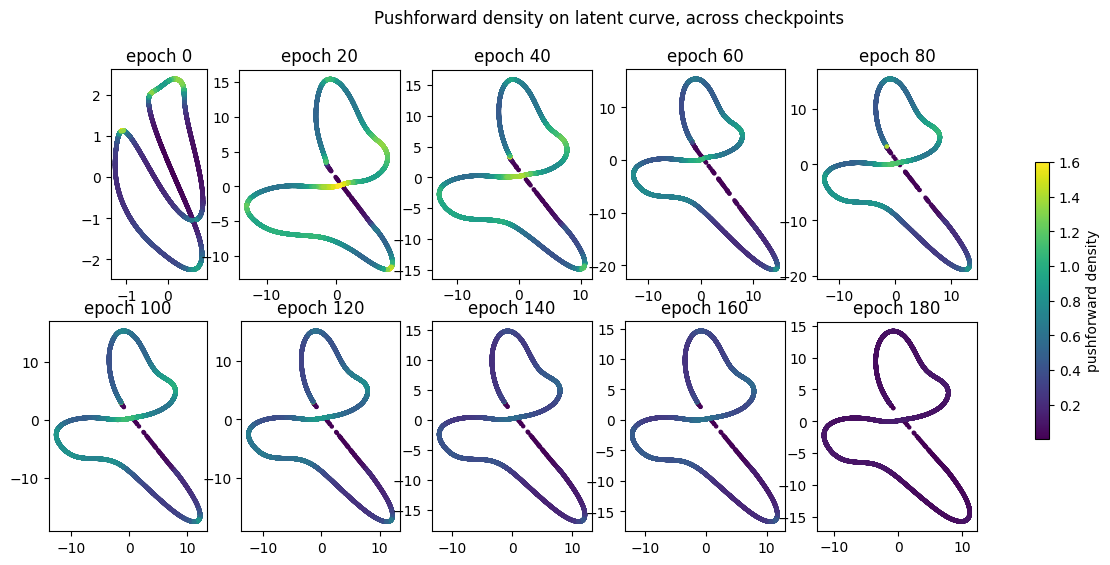

In [6]:
ckpt_paths = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "vae_epoch*.pt")))
n_ckpts = len(ckpt_paths)
ncols = 5
nrows = int(np.ceil(n_ckpts / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, path in zip(axes, ckpt_paths):
    epoch = int(os.path.basename(path).replace("vae_epoch", "").replace(".pt", ""))
    ckpt_model = VAE(X.shape[1]).to(device)
    ckpt_model.load_state_dict(torch.load(path, map_location=device))
    ckpt_model.eval()

    theta_sorted, ds, kappa2, rho = latent_curve_quantities(ckpt_model, thetas, device)

    with torch.no_grad():
        mu, _ = ckpt_model.encode(X.to(device))
    Z_ckpt = mu.cpu().numpy()

    # rho/ds/kappa2 are sorted by theta; resort the matching density values back to imgs/thetas order
    order = np.argsort(thetas)
    rho_unsorted = np.empty_like(rho)
    rho_unsorted[order] = rho

    sc = ax.scatter(Z_ckpt[:, 0], Z_ckpt[:, 1], c=rho_unsorted, cmap="viridis", s=5)
    ax.set_title(f"epoch {epoch}")
    ax.set_aspect("equal")

for ax in axes[n_ckpts:]:
    ax.axis("off")

fig.colorbar(sc, ax=axes[:n_ckpts].tolist(), label="pushforward density", shrink=0.6)
fig.suptitle("Pushforward density on latent curve, across checkpoints")
plt.show()


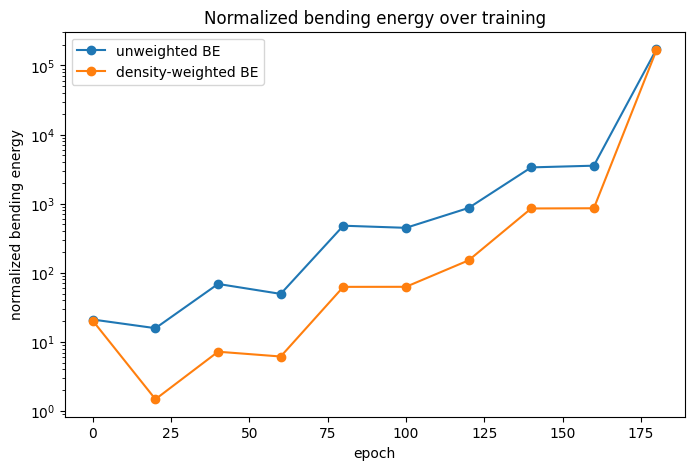

In [ ]:
epochs = []
be_history = []
wbe_history = []

for path in ckpt_paths:
    epoch = int(os.path.basename(path).replace("vae_epoch", "").replace(".pt", ""))
    ckpt_model = VAE(X.shape[1]).to(device)
    ckpt_model.load_state_dict(torch.load(path, map_location=device))
    ckpt_model.eval()

    theta_sorted, ds, kappa2, rho = latent_curve_quantities(ckpt_model, thetas, device)
    be = normalized_bending_energy(theta_sorted, ds, kappa2)
    wbe = normalized_weighted_bending_energy(theta_sorted, ds, kappa2, rho)

    epochs.append(epoch)
    be_history.append(be)
    wbe_history.append(wbe)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, be_history, marker="o", label="unweighted BE")
ax.plot(epochs, wbe_history, marker="o", label="density-weighted BE")
ax.set_xlabel("epoch")
ax.set_ylabel("normalized bending energy")
ax.set_yscale("log")
ax.set_title("Normalized bending energy over training")
ax.legend()
plt.show()


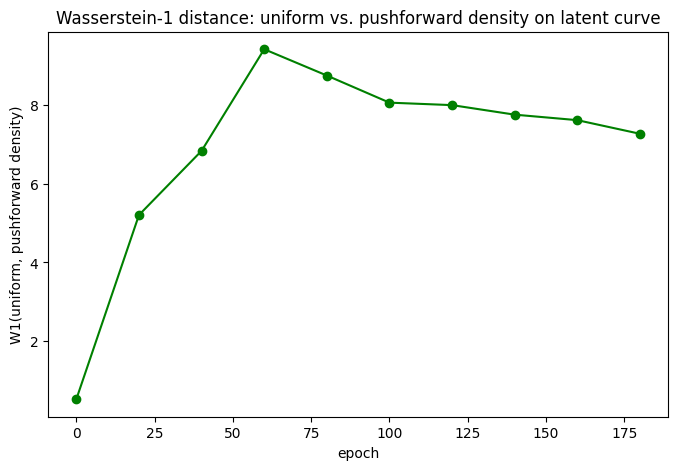

In [ ]:
def w1_uniform_vs_pushforward(theta_sorted, ds, rho):
    """W1 distance between Unif[0, L] (arclength) and the pushforward density rho(s), on the closed curve."""
    dtheta, (ds_mid, rho_mid) = _close_loop_trapz(theta_sorted, ds, rho)
    ds_steps = ds_mid * dtheta  # segment lengths in arclength
    s_edges = np.concatenate([[0.0], np.cumsum(ds_steps)])
    L = s_edges[-1]

    mass_steps = rho_mid * ds_steps
    cdf_rho = np.concatenate([[0.0], np.cumsum(mass_steps)])
    cdf_rho = cdf_rho / cdf_rho[-1]  # normalize to a proper CDF
    cdf_uniform = s_edges / L

    return np.trapezoid(np.abs(cdf_rho - cdf_uniform), s_edges)

# sanity check: rho itself uniform -> W1 should be ~0
_rho_uniform_check = np.ones_like(kappa2)  # any constant works, normalized internally
print("W1(uniform, uniform):", w1_uniform_vs_pushforward(theta_sorted, ds, _rho_uniform_check))

w1_history = []
for path in ckpt_paths:
    ckpt_model = VAE(X.shape[1]).to(device)
    ckpt_model.load_state_dict(torch.load(path, map_location=device))
    ckpt_model.eval()

    theta_sorted_c, ds_c, kappa2_c2, rho_c = latent_curve_quantities(ckpt_model, thetas, device)
    w1_history.append(w1_uniform_vs_pushforward(theta_sorted_c, ds_c, rho_c))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, w1_history, marker="o", color="green")
ax.set_xlabel("epoch")
ax.set_ylabel("W1(uniform, pushforward density)")
ax.set_title("Wasserstein-1 distance: uniform vs. pushforward density on latent curve")
plt.show()
